# ✈️ Flight Fare Prediction using Machine Learning

**Author:** Amir Nawed  
**Project Type:** Supervised Machine Learning – Regression  
**Goal:** Predict the price of a flight ticket based on features like airline, source, destination, duration, stops, etc.

---

### 📌 Dataset Overview
- **Rows:** 10,683  |  **Columns:** 11  |  **Target:** `Price` (INR)
- **Missing Values:** 2  |  **Duplicates:** 220  |  **Problem:** Regression

### 🔁 Project Workflow
1. Import Libraries → 2. Load Data → 3. EDA → 4. Data Cleaning  
5. Feature Engineering → 6. Encoding → 7. Train 5 Models → 8. Compare  
9. Tune RF + XGBoost → 10. Pick Best → 11. Save Model


## Step 1: Import Libraries

In [1]:
# ─── Import all the libraries we need ───────────────────────────────────────

import pandas as pd           # for data handling (like Excel in Python)
import numpy as np            # for math operations
import matplotlib.pyplot as plt  # for plotting graphs
import seaborn as sns         # for better-looking graphs
import warnings
warnings.filterwarnings('ignore')  # hide unnecessary warnings so output stays clean

# For building and evaluating ML models
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder   # converts text → numbers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 5 ML Models we will try and compare
from sklearn.linear_model import LinearRegression          # simplest model — baseline
from sklearn.tree import DecisionTreeRegressor             # single tree model
from sklearn.ensemble import RandomForestRegressor         # many trees — usually best
from sklearn.ensemble import GradientBoostingRegressor     # trees built one by one
from sklearn.ensemble import ExtraTreesRegressor           # like RF but more random
from xgboost import XGBRegressor        # powerful boosting model — often best for tabular data

import pickle   # to save our final trained model to disk

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load the Dataset

In [2]:
# ─── Load the Excel file into a DataFrame ────────────────────────────────────
# DataFrame is like a table (rows and columns), same as an Excel sheet in Python
# read_excel() reads .xlsx files — needs 'openpyxl' library installed

df = pd.read_excel("Flight_Fare.xlsx")

print("Shape of dataset (rows, columns):", df.shape)
print()
df.head()   # show first 5 rows to understand the data

Shape of dataset (rows, columns): (10683, 11)



,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
# ─── Check column names and data types ───────────────────────────────────────
# df.info() shows us:
#   - Column names
#   - Data type of each column (int, float, object = text)
#   - How many non-null (non-missing) values each column has

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [4]:
# ─── Check for missing values and duplicates ─────────────────────────────────
# isnull().sum() counts how many NaN (empty) values are in each column
# duplicated().sum() counts rows that are exactly the same as another row

print("Missing values in each column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values in each column:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

Duplicate rows: 220


In [5]:
# ─── Basic statistics of the Price column (our target) ───────────────────────
# describe() gives us: count, mean, min, max, 25th/50th/75th percentile
# This helps us understand the range and distribution of flight prices

print("Price Statistics:")
df['Price'].describe()

Price Statistics:


count    10683.000000
mean      9087.064121
std       4611.359167
min       1759.000000
25%       5277.000000
50%       8372.000000
75%      12373.000000
max      79512.000000
Name: Price, dtype: float64

In [6]:
# ─── See unique values in each categorical column ────────────────────────────
# This tells us how many different categories exist in each column
# For example: how many airlines? how many sources? what are the stop options?
# This is important before encoding — we need to know what we are dealing with

for col in ['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info']:
    print(f"{col}: {df[col].nunique()} unique values → {df[col].unique().tolist()}")
    print()

Airline: 12 unique values → ['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet', 'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia', 'Vistara Premium economy', 'Jet Airways Business', 'Multiple carriers Premium economy', 'Trujet']

Source: 5 unique values → ['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai']

Destination: 6 unique values → ['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']

Total_Stops: 5 unique values → ['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops']

Additional_Info: 10 unique values → ['No info', 'In-flight meal not included', 'No check-in baggage included', '1 Short layover', 'No Info', '1 Long layover', 'Change airports', 'Business class', 'Red-eye flight', '2 Long layover']



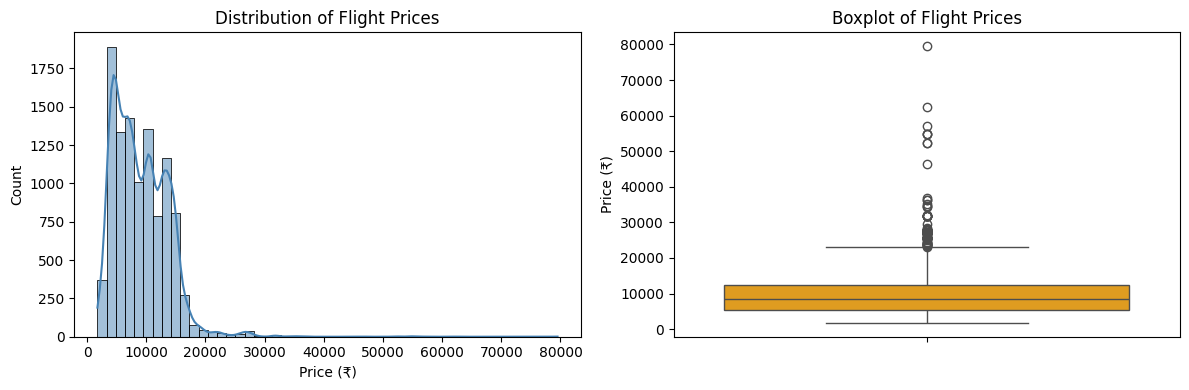

In [7]:
# ─── Visualize Price distribution ─────────────────────────────────────────────
# Histogram shows: how are prices spread? Are most flights cheap or expensive?
# KDE (Kernel Density Estimate) = smooth curve over the histogram
# Boxplot shows: median, Q1, Q3, and outliers (dots outside the whiskers)
# If we see a right-skewed histogram → most flights are cheap, few are very expensive

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Price'], bins=50, kde=True, color='steelblue')
plt.title("Distribution of Flight Prices")
plt.xlabel("Price (₹)")

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Price'], color='orange')
plt.title("Boxplot of Flight Prices")
plt.ylabel("Price (₹)")

plt.tight_layout()
plt.show()

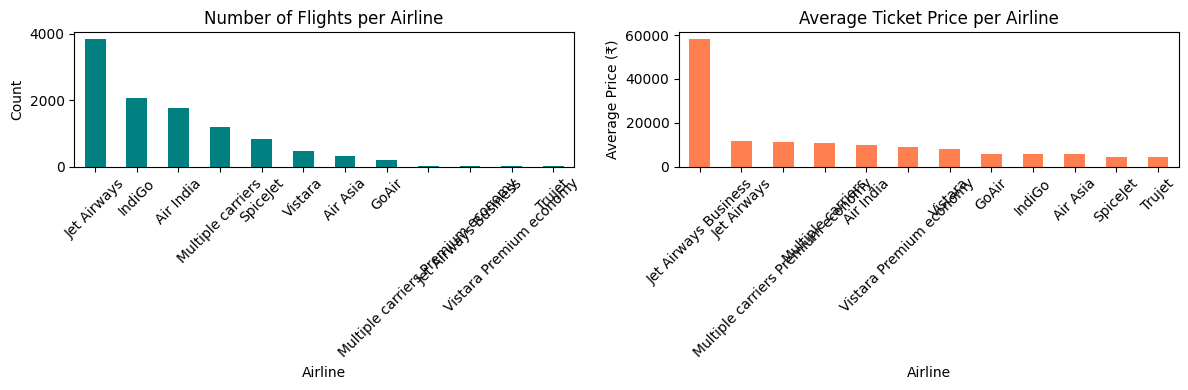

In [8]:
# ─── Airline-wise analysis ─────────────────────────────────────────────────────
# Left chart: Which airline has the most flights in our dataset?
# Right chart: Which airline charges the most on average?
# This is important — airline is likely a strong predictor of price

plt.figure(figsize=(12, 4))

# Left: count of flights per airline
plt.subplot(1, 2, 1)
df['Airline'].value_counts().plot(kind='bar', color='teal')
plt.title("Number of Flights per Airline")
plt.xlabel("Airline")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Right: average price per airline
plt.subplot(1, 2, 2)
df.groupby('Airline')['Price'].mean().sort_values(ascending=False).plot(kind='bar', color='coral')
plt.title("Average Ticket Price per Airline")
plt.xlabel("Airline")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Step 4: Data Cleaning

1. Remove 220 duplicate rows
2. Drop 2 rows with missing values (very few — safe to drop)


In [9]:
# ─── Step 4: Data Cleaning ────────────────────────────────────────────────────

# --- Remove duplicate rows ---
# 220 rows were exactly the same as another row
# Keeping them would make the model learn those patterns twice → overfitting
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates :", df.shape)

# --- Drop rows with missing values ---
# We only have 2 missing rows (1 in Route, 1 in Total_Stops)
# 2 out of 10,000+ rows = 0.02% — very safe to drop
# No imputation needed for such a tiny number
df = df.dropna()
print("After dropping missing rows:", df.shape)

Before removing duplicates: (10683, 11)
After removing duplicates : (10463, 11)
After dropping missing rows: (10462, 11)


## Step 5: Feature Engineering

ML models only understand numbers — not text like "24/03/2019" or "2h 50m".  
We extract useful numbers from date, time, and duration columns.


In [10]:
# --- Extract Day and Month from Date_of_Journey ---
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
df['Journey_Day']     = df['Date_of_Journey'].dt.day
df['Journey_Month']   = df['Date_of_Journey'].dt.month
df.drop(columns=['Date_of_Journey'], inplace=True)
print("Journey Day & Month extracted!")


Journey Day & Month extracted!


In [11]:
# --- Extract Hour and Minute from Dep_Time ---
df['Dep_Hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
df['Dep_Min']  = pd.to_datetime(df['Dep_Time']).dt.minute
df.drop(columns=['Dep_Time'], inplace=True)
print("Departure Hour & Min extracted!")


Departure Hour & Min extracted!


In [12]:
# --- Extract Hour and Minute from Arrival_Time ---
# Arrival_Time sometimes has extra date info like "01:10 22 Mar" — we take only "01:10"
df['Arrival_Time_Clean'] = df['Arrival_Time'].apply(lambda x: x.split(' ')[0])
df['Arrival_Hour'] = pd.to_datetime(df['Arrival_Time_Clean']).dt.hour
df['Arrival_Min']  = pd.to_datetime(df['Arrival_Time_Clean']).dt.minute
df.drop(columns=['Arrival_Time', 'Arrival_Time_Clean'], inplace=True)
print("Arrival Hour & Min extracted!")


Arrival Hour & Min extracted!


In [13]:
# --- Convert Duration to total minutes ---
# "2h 50m" → 2*60 + 50 = 170 minutes

def convert_duration_to_minutes(duration):
    hours = 0
    minutes = 0
    if 'h' in duration:
        parts = duration.split('h')
        hours = int(parts[0].strip())
        if 'm' in parts[1]:
            minutes = int(parts[1].replace('m', '').strip())
    elif 'm' in duration:
        minutes = int(duration.replace('m', '').strip())
    return hours * 60 + minutes

df['Duration_Minutes'] = df['Duration'].apply(convert_duration_to_minutes)
df.drop(columns=['Duration'], inplace=True)
print("Duration converted to minutes!")
print(df['Duration_Minutes'].describe())


Duration converted to minutes!
count    10462.000000
mean       629.781591
std        500.699045
min          5.000000
25%        170.000000
50%        505.000000
75%        910.000000
max       2860.000000
Name: Duration_Minutes, dtype: float64


In [14]:
# --- Convert Total_Stops to number ---
stops_mapping = {'non-stop':0, '1 stop':1, '2 stops':2, '3 stops':3, '4 stops':4}
df['Total_Stops'] = df['Total_Stops'].map(stops_mapping)
print("Total_Stops converted!")
print(df['Total_Stops'].value_counts())


Total_Stops converted!
1    5625
0    3475
2    1318
3      43
4       1
Name: Total_Stops, dtype: int64


In [15]:
# --- Drop Route column ---
# Route info is already captured by Source, Destination & Total_Stops
df.drop(columns=['Route'], inplace=True)
print("Route dropped! Current columns:", df.columns.tolist())


Route dropped! Current columns: ['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min', 'Arrival_Hour', 'Arrival_Min', 'Duration_Minutes']


## Step 6: Encode Categorical Columns

ML models need numbers — not text like "IndiGo" or "Delhi".  
We use **LabelEncoder** to convert each category to a number.  
We also **save each encoder** so the Streamlit app can use the same mapping for new inputs.


In [16]:
# ─── Encode Categorical Columns using LabelEncoder ───────────────────────────
# ML models only understand numbers — not text like "IndiGo" or "Delhi"
# LabelEncoder assigns a unique number to each category
#   Example: IndiGo=0, Air India=1, Jet Airways=2, etc.
#
# IMPORTANT: We save each encoder in a dictionary called 'encoders'
# Why? Because when a new user gives input in Streamlit app,
# we need the SAME mapping to encode their input correctly
# If we don't save encoders, app will give wrong predictions!

cat_cols = ['Airline', 'Source', 'Destination', 'Additional_Info']

encoders = {}   # empty dictionary — will store one encoder per column

for col in cat_cols:
    le = LabelEncoder()               # create a new encoder
    df[col] = le.fit_transform(df[col])   # fit on data AND transform it
    encoders[col] = le                # save this encoder for later use
    print(f"✅ {col} encoded  |  Classes: {le.classes_.tolist()}")

print()
print("All categorical columns encoded!")
print("'encoders' dictionary will be saved as encoders.pkl for the Streamlit app")
df.head()

✅ Airline encoded  |  Classes: ['Air Asia', 'Air India', 'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business', 'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet', 'Trujet', 'Vistara', 'Vistara Premium economy']
✅ Source encoded  |  Classes: ['Banglore', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai']
✅ Destination encoded  |  Classes: ['Banglore', 'Cochin', 'Delhi', 'Hyderabad', 'Kolkata', 'New Delhi']
✅ Additional_Info encoded  |  Classes: ['1 Long layover', '1 Short layover', '2 Long layover', 'Business class', 'Change airports', 'In-flight meal not included', 'No Info', 'No check-in baggage included', 'No info', 'Red-eye flight']

All categorical columns encoded!
'encoders' dictionary will be saved as encoders.pkl for the Streamlit app


,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Minutes
0,3,0,5,0,8,3897,24,3,22,20,1,10,170
1,1,3,0,2,8,7662,1,5,5,50,13,15,445
2,4,2,1,2,8,13882,9,6,9,25,4,25,1140
3,3,3,0,1,8,6218,12,5,18,5,23,30,325
4,3,0,5,1,8,13302,1,3,16,50,21,35,285


## Step 7: Correlation Heatmap

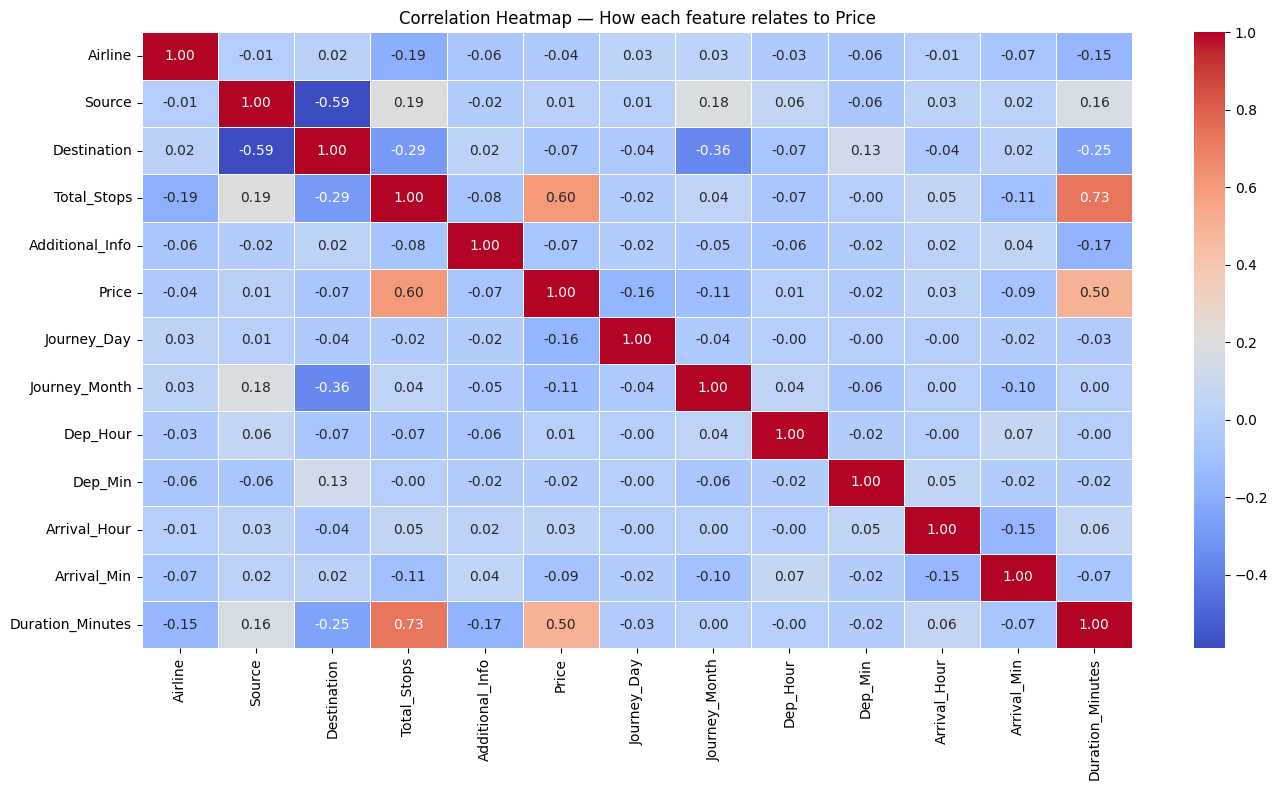

In [17]:
# ─── Correlation Heatmap ──────────────────────────────────────────────────────
# Correlation tells us: if one feature increases, does Price also increase or decrease?
#
# Values close to +1 = strong positive relationship (both go up together)
# Values close to -1 = strong negative relationship (one goes up, other goes down)
# Values close to  0 = weak or no relationship
#
# We are especially interested in the last row/column: correlation with 'Price'
# Higher absolute value = more important feature for predicting price

plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap — How each feature relates to Price")
plt.tight_layout()
plt.show()

## Step 8: Prepare Features and Split Data

- **X** = all columns except Price (input features)
- **y** = Price column (what we want to predict)
- Split: 80% train, 20% test


In [18]:
# ─── Separate Features (X) and Target (y) ────────────────────────────────────
# X = all columns except Price → these are our INPUT features (what we give to the model)
# y = only Price column → this is our OUTPUT / TARGET (what the model has to predict)
#
# Think of it like this:
#   X = question paper (airline, stops, duration, etc.)
#   y = answer key (actual price)

X = df.drop(columns=['Price'])   # everything except Price
y = df['Price']                  # only Price

print("X shape (features):", X.shape)
print("y shape (target)  :", y.shape)
print()
print("Feature columns:", X.columns.tolist())

X shape (features): (10462, 12)
y shape (target)  : (10462,)

Feature columns: ['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min', 'Arrival_Hour', 'Arrival_Min', 'Duration_Minutes']


In [19]:
# ─── Split Data into Train and Test Sets ─────────────────────────────────────
# We split data into 2 parts:
#   Training set (80%) → model learns from this data
#   Testing set  (20%) → we test model on data it has NEVER seen before
#
# Why test on unseen data?
# If we test on the same data we trained on, model will score 100% — but that's cheating!
# Real performance = how well model does on NEW, unseen data
#
# random_state=42 → ensures same split every time we run this cell (reproducibility)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% data for testing, 80% for training
    random_state=42     # same result every time
)

print("Training set size :", X_train.shape)
print("Testing set size  :", X_test.shape)

Training set size : (8369, 12)
Testing set size  : (2093, 12)


## Step 9: Train 5 Baseline Models & Compare

In [20]:
# ─── Helper Function to Evaluate Any Model ───────────────────────────────────
# Instead of writing evaluation code 5 times (once per model),
# we write it once as a function and call it for each model
#
# Metrics we use:
#   MAE  = Mean Absolute Error → average error in rupees (easy to understand)
#           Example: MAE=800 means on average, prediction is ₹800 off
#   RMSE = Root Mean Squared Error → penalizes BIG errors more than small ones
#           Example: predicting ₹5000 instead of ₹15000 is punished more
#   R2   = R-squared score → how much variance in price does model explain?
#           R2=0.88 means model explains 88% of price variation — very good!
#           R2=1.0 = perfect, R2=0.0 = model is useless

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    # Step 1: Train the model on training data
    model.fit(X_train, y_train)

    # Step 2: Make predictions on test data (data model has never seen)
    y_pred = model.predict(X_test)

    # Step 3: Calculate how far off our predictions are
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    # Step 4: Print results
    print(f"📊 {model_name}")
    print(f"   MAE  (avg ₹ error) : ₹{mae:.2f}")
    print(f"   RMSE               : ₹{rmse:.2f}")
    print(f"   R2 Score           : {r2:.4f}")
    print()

    # Step 5: Return results as dictionary so we can compare later
    return {'Model': model_name, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R2': round(r2,4)}

In [21]:
# ─── Model 1: Linear Regression ──────────────────────────────────────────────
# Simplest ML model. Draws a straight line through data.
# Assumes: if duration doubles, price also doubles (linear relationship)
# Good for: baseline comparison — if other models can't beat this, something is wrong
# Weakness: flight prices are NOT linear — many complex patterns exist

lr_results = evaluate_model(
    LinearRegression(),
    X_train, X_test, y_train, y_test,
    'Linear Regression'
)

📊 Linear Regression
   MAE  (avg ₹ error) : ₹2451.39
   RMSE               : ₹3401.88
   R2 Score           : 0.4450



In [22]:
# ─── Model 2: Decision Tree Regressor ────────────────────────────────────────
# Creates a tree of if-else conditions to make predictions
# Example: IF airline=IndiGo AND stops=0 AND duration<120 → price ≈ ₹3500
# Advantage: easy to understand, handles non-linear patterns
# Weakness: tends to overfit (memorize training data, fail on new data)

dt_results = evaluate_model(
    DecisionTreeRegressor(random_state=42),
    X_train, X_test, y_train, y_test,
    'Decision Tree'
)

📊 Decision Tree
   MAE  (avg ₹ error) : ₹803.44
   RMSE               : ₹1904.36
   R2 Score           : 0.8261



In [23]:
# ─── Model 3: Random Forest Regressor ────────────────────────────────────────
# Builds 100 different Decision Trees, each on a random subset of data
# Final prediction = average of all 100 trees
# Why better than single tree? Because 100 different opinions are better than 1
# This is called "ensemble learning" — combining many weak models into one strong model
# n_estimators=100 → build 100 trees

rf_results = evaluate_model(
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test,
    'Random Forest'
)

📊 Random Forest
   MAE  (avg ₹ error) : ₹703.49
   RMSE               : ₹1552.11
   R2 Score           : 0.8845



In [24]:
# ─── Model 4: Extra Trees Regressor ──────────────────────────────────────────
# Very similar to Random Forest — also builds many trees and averages them
# Key difference: Random Forest finds the BEST split at each node
#                 Extra Trees uses a RANDOM split → even more randomness
# This extra randomness sometimes reduces overfitting further
# Faster than Random Forest because it doesn't search for best split

et_results = evaluate_model(
    ExtraTreesRegressor(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test,
    'Extra Trees'
)

📊 Extra Trees
   MAE  (avg ₹ error) : ₹662.05
   RMSE               : ₹1562.38
   R2 Score           : 0.8829



In [25]:
# ─── Model 5: Gradient Boosting Regressor ────────────────────────────────────
# Builds trees SEQUENTIALLY — one by one (unlike Random Forest which is parallel)
# Each new tree tries to fix the MISTAKES (residuals) of the previous tree
# Tree 1: makes predictions, has some errors
# Tree 2: focuses on those errors and tries to fix them
# Tree 3: fixes remaining errors... and so on
# Result: very accurate, but slower to train than Random Forest

gb_results = evaluate_model(
    GradientBoostingRegressor(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test,
    'Gradient Boosting'
)

📊 Gradient Boosting
   MAE  (avg ₹ error) : ₹1266.08
   RMSE               : ₹2014.38
   R2 Score           : 0.8054



## Step 10: Baseline Model Comparison

In [26]:
# ─── Compare All Baseline Models in a Table ──────────────────────────────────
# Put all 5 results into a DataFrame for easy side-by-side comparison
# sorted by R2 score — highest R2 model appears first (that's our best baseline)

baseline_df = pd.DataFrame([lr_results, dt_results, rf_results, et_results, gb_results])
baseline_df = baseline_df.sort_values('R2', ascending=False).reset_index(drop=True)

print("=== Baseline Model Comparison (sorted by R2 Score) ===")
print(baseline_df.to_string(index=False))

=== Baseline Model Comparison (sorted by R2 Score) ===
            Model     MAE    RMSE     R2
    Random Forest  703.49 1552.11 0.8845
      Extra Trees  662.05 1562.38 0.8829
    Decision Tree  803.44 1904.36 0.8261
Gradient Boosting 1266.08 2014.38 0.8054
Linear Regression 2451.39 3401.88 0.4450


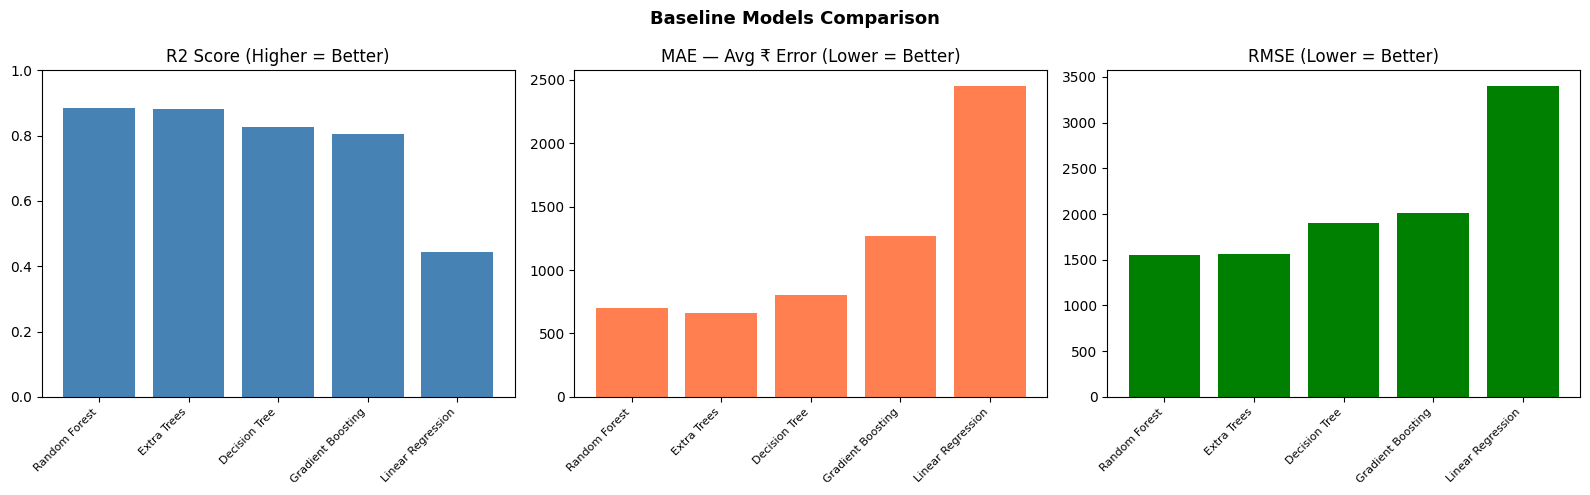

In [27]:
# ─── Visualize Baseline Model Comparison ─────────────────────────────────────
# 3 bar charts — one for each metric
# R2:   higher bar = better model
# MAE:  lower bar = better model (less error in rupees)
# RMSE: lower bar = better model

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: R2 Score
axes[0].bar(baseline_df['Model'], baseline_df['R2'], color='steelblue')
axes[0].set_title("R2 Score (Higher = Better)")
axes[0].set_xticklabels(baseline_df['Model'], rotation=45, ha='right', fontsize=8)
axes[0].set_ylim(0, 1)   # R2 ranges from 0 to 1

# Chart 2: MAE
axes[1].bar(baseline_df['Model'], baseline_df['MAE'], color='coral')
axes[1].set_title("MAE — Avg ₹ Error (Lower = Better)")
axes[1].set_xticklabels(baseline_df['Model'], rotation=45, ha='right', fontsize=8)

# Chart 3: RMSE
axes[2].bar(baseline_df['Model'], baseline_df['RMSE'], color='green')
axes[2].set_title("RMSE (Lower = Better)")
axes[2].set_xticklabels(baseline_df['Model'], rotation=45, ha='right', fontsize=8)

plt.suptitle("Baseline Models Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 11: Hyperparameter Tuning — Random Forest vs XGBoost

We tune both models and pick the winner automatically.

**What is XGBoost?**  
Builds trees sequentially — each tree **corrects the mistakes** of the previous one.  
Industry favourite for tabular price prediction problems.


In [28]:
# --- Tune Random Forest ---
rf_param_grid = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [None, 15, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2']
}
print("Tuning Random Forest... please wait")
rf_tuned = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=30, cv=3, scoring='r2', n_jobs=-1, random_state=42, verbose=1
)
rf_tuned.fit(X_train, y_train)
print("\n✅ Random Forest tuning done!")
print("Best RF params:", rf_tuned.best_params_)


Tuning Random Forest... please wait
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ Random Forest tuning done!
Best RF params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [29]:
# ─── Evaluate Tuned Random Forest ────────────────────────────────────────────
# Use the best model found by RandomizedSearchCV to predict on test data
# Then calculate all 3 metrics to see improvement over baseline

y_pred_rf_tuned = rf_tuned.best_estimator_.predict(X_test)

rf_mae  = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
rf_r2   = r2_score(y_test, y_pred_rf_tuned)

print("📊 Tuned Random Forest Results:")
print(f"   MAE  : ₹{rf_mae:.2f}  |  RMSE : ₹{rf_rmse:.2f}  |  R2 : {rf_r2:.4f}")
print()
print(f"Improvement from baseline RF R2: {rf_results['R2']} → {round(rf_r2, 4)}")

📊 Tuned Random Forest Results:
   MAE  : ₹769.29  |  RMSE : ₹1584.44  |  R2 : 0.8796

Improvement from baseline RF R2: 0.8845 → 0.8796


In [30]:
# --- Tune XGBoost ---
# learning_rate : how fast model learns (lower = more careful = usually better)
# subsample     : % of rows each tree sees
# colsample_bytree: % of features each tree uses
xgb_param_grid = {
    'n_estimators'    : [200, 300, 500],
    'max_depth'       : [3, 5, 7, 9],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}
print("Tuning XGBoost... please wait")
xgb_tuned = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_distributions=xgb_param_grid,
    n_iter=30, cv=3, scoring='r2', n_jobs=-1, random_state=42, verbose=1
)
xgb_tuned.fit(X_train, y_train)
print("\n✅ XGBoost tuning done!")
print("Best XGB params:", xgb_tuned.best_params_)


Tuning XGBoost... please wait
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ XGBoost tuning done!
Best XGB params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [31]:
# ─── Evaluate Tuned XGBoost ───────────────────────────────────────────────────
# Same evaluation as Random Forest — predict, then calculate metrics

y_pred_xgb_tuned = xgb_tuned.best_estimator_.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, y_pred_xgb_tuned)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
xgb_r2   = r2_score(y_test, y_pred_xgb_tuned)

print("📊 Tuned XGBoost Results:")
print(f"   MAE  : ₹{xgb_mae:.2f}  |  RMSE : ₹{xgb_rmse:.2f}  |  R2 : {xgb_r2:.4f}")

📊 Tuned XGBoost Results:
   MAE  : ₹740.57  |  RMSE : ₹1534.92  |  R2 : 0.8870


## Step 12: Final Model Comparison — Who Wins?

In [32]:
# ─── Final Comparison — All Models Together ──────────────────────────────────
# Now we compare ALL 7 models:
#   5 baseline models (without tuning)
#   2 tuned models (Random Forest Tuned + XGBoost Tuned)
# This shows clearly how much improvement hyperparameter tuning gave us

all_results = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    et_results,
    gb_results,
    {'Model': 'Random Forest (Tuned)', 'MAE': round(rf_mae,2),  'RMSE': round(rf_rmse,2),  'R2': round(rf_r2,4)},
    {'Model': 'XGBoost (Tuned)',       'MAE': round(xgb_mae,2), 'RMSE': round(xgb_rmse,2), 'R2': round(xgb_r2,4)},
])

# Sort by R2 — best model at top
all_results = all_results.sort_values('R2', ascending=False).reset_index(drop=True)

print("=== FINAL MODEL COMPARISON (sorted by R2 Score) ===")
print(all_results.to_string(index=False))

=== FINAL MODEL COMPARISON (sorted by R2 Score) ===
                Model     MAE    RMSE     R2
      XGBoost (Tuned)  740.57 1534.92 0.8870
        Random Forest  703.49 1552.11 0.8845
          Extra Trees  662.05 1562.38 0.8829
Random Forest (Tuned)  769.29 1584.44 0.8796
        Decision Tree  803.44 1904.36 0.8261
    Gradient Boosting 1266.08 2014.38 0.8054
    Linear Regression 2451.39 3401.88 0.4450


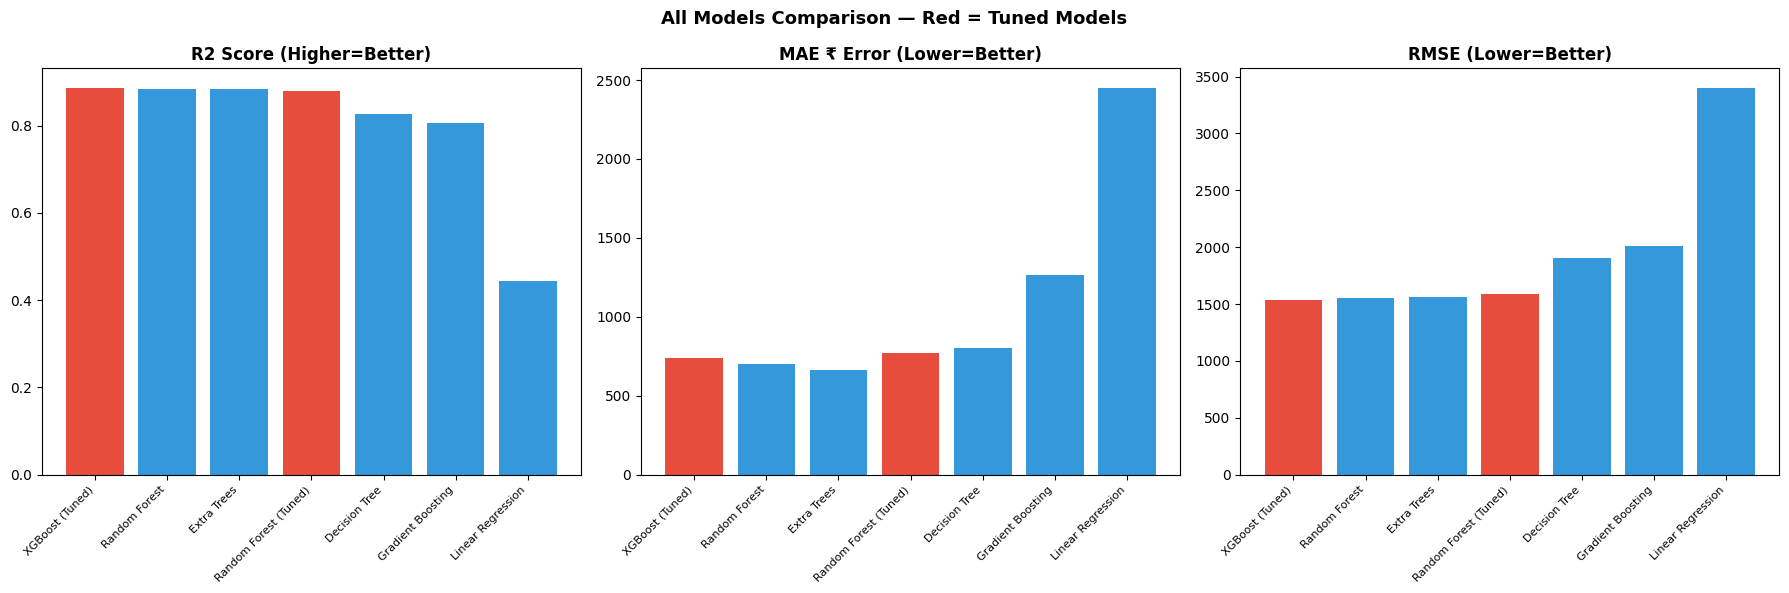

In [33]:
# ─── Visualize Final Comparison ───────────────────────────────────────────────
# Red bars = tuned models → should be the tallest (best R2) / shortest (lowest error)
# Blue bars = baseline models
# This visualization clearly shows: tuning improved our model!

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#e74c3c' if 'Tuned' in m else '#3498db' for m in all_results['Model']]

for ax, metric, title in zip(
    axes,
    ['R2', 'MAE', 'RMSE'],
    ['R2 Score (Higher=Better)', 'MAE ₹ Error (Lower=Better)', 'RMSE (Lower=Better)']
):
    ax.bar(all_results['Model'], all_results[metric], color=colors)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(all_results['Model'], rotation=45, ha='right', fontsize=8)

plt.suptitle("All Models Comparison — Red = Tuned Models", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
# ─── Automatically Pick the Best Model ───────────────────────────────────────
# We compare R2 of tuned XGBoost vs tuned Random Forest
# Whichever is higher → that becomes our FINAL model
# This is stored in 'best_final_model' variable and used for everything after this

if xgb_r2 >= rf_r2:
    best_final_model = xgb_tuned.best_estimator_   # XGBoost model object
    best_model_name  = "XGBoost (Tuned)"
    best_r2_final    = xgb_r2
    best_mae_final   = xgb_mae
    y_pred_final     = y_pred_xgb_tuned             # predictions from XGBoost
else:
    best_final_model = rf_tuned.best_estimator_     # Random Forest model object
    best_model_name  = "Random Forest (Tuned)"
    best_r2_final    = rf_r2
    best_mae_final   = rf_mae
    y_pred_final     = y_pred_rf_tuned              # predictions from Random Forest

print(f"🏆 WINNER: {best_model_name}")
print(f"   R2 Score        : {best_r2_final:.4f}  →  model explains {best_r2_final*100:.1f}% of price variation")
print(f"   Avg Error (MAE) : ₹{best_mae_final:.2f}  →  on average prediction is only ₹{best_mae_final:.0f} off")

🏆 WINNER: XGBoost (Tuned)
   R2 Score        : 0.8870  →  model explains 88.7% of price variation
   Avg Error (MAE) : ₹740.57  →  on average prediction is only ₹741 off


## Step 13: Feature Importance

Which features affect flight price the most?

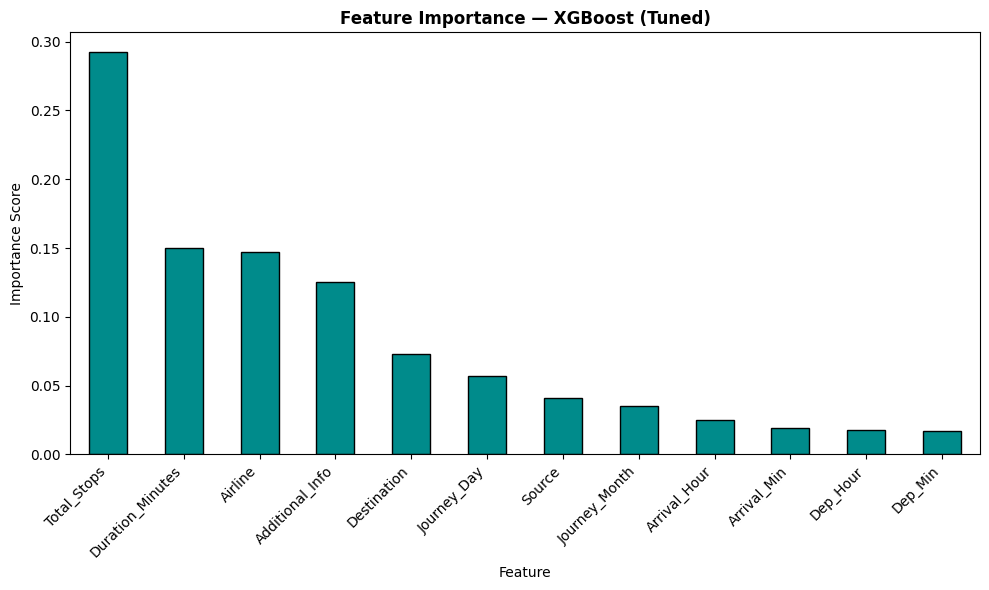

Top 5 features that affect price the most:
Total_Stops         0.292171
Duration_Minutes    0.149723
Airline             0.147028
Additional_Info     0.125541
Destination         0.072890
dtype: float32


In [35]:
# ─── Feature Importance ───────────────────────────────────────────────────────
# After training, the model internally knows which features were most useful
# feature_importances_ gives a score to each feature (all scores sum to 1.0)
#
# Higher score = that feature was used more in making predictions = more important
# This helps us understand: what actually drives flight prices?
# Useful insight for business understanding too!

importances = pd.Series(best_final_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)   # sort: most important first

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='darkcyan', edgecolor='black')
plt.title(f"Feature Importance — {best_model_name}", fontweight='bold')
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 features that affect price the most:")
print(importances.head())

## Step 14: Actual vs Predicted Price

Perfect model = all points on the red diagonal line.

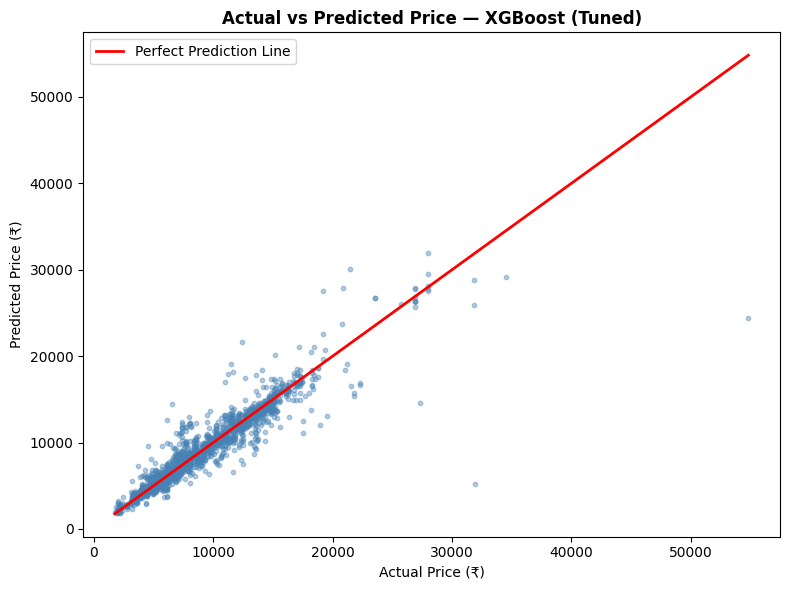

In [36]:
# ─── Actual vs Predicted Price Plot ──────────────────────────────────────────
# This is a scatter plot:
#   X-axis = Actual price (what the real ticket cost)
#   Y-axis = Predicted price (what our model guessed)
#
# The RED diagonal line = perfect prediction line (actual = predicted)
# If all dots were ON the red line → model is 100% perfect
# The closer dots are to the red line → the better our model is
# Dots far from the line = those specific predictions had big errors

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.4, color='steelblue', s=10)

# Draw the perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linewidth=2, label='Perfect Prediction Line'
)

plt.title(f"Actual vs Predicted Price — {best_model_name}", fontweight='bold')
plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.legend()
plt.tight_layout()
plt.show()

## Step 15: Save Best Model + Encoders

Both files are needed for the Streamlit web app:
- `flight_fare_model.pkl` → the trained model
- `encoders.pkl` → LabelEncoders (to process new user input)


In [37]:
# ─── Save the Best Model and Encoders ────────────────────────────────────────
# We save 2 files using pickle (Python's way of saving objects to disk):
#
# 1. flight_fare_model.pkl → the trained ML model
#    Why save? So we don't have to retrain every time — just load and predict
#
# 2. encoders.pkl → all 4 LabelEncoders in a dictionary
#    Why save? Streamlit app needs same encoding for new user inputs
#    If we don't save encoders, app will encode differently and give wrong predictions!
#
# "wb" = write binary mode (required for pickle files)

with open("flight_fare_model.pkl", "wb") as f:
    pickle.dump(best_final_model, f)

with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print(f"✅ Model saved   : flight_fare_model.pkl  ({best_model_name})")
print(f"✅ Encoders saved: encoders.pkl")
print()
print("Both files + app.py are needed to run the Streamlit web app!")

✅ Model saved   : flight_fare_model.pkl  (XGBoost (Tuned))
✅ Encoders saved: encoders.pkl

Both files + app.py are needed to run the Streamlit web app!


In [38]:
# ─── Test: Load the Saved Model and Make a Sample Prediction ─────────────────
# This verifies that:
#   1. Our model was saved correctly
#   2. Loading and predicting works fine
#   3. Prediction is close to the actual price
#
# "rb" = read binary mode (required for loading pickle files)
# We take the very first row of test data as our sample

# Load the saved model from disk
with open("flight_fare_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Take one sample from test data
sample       = X_test.iloc[[0]]     # double brackets → keeps it as DataFrame (not Series)
pred_price   = loaded_model.predict(sample)[0]
actual_price = y_test.iloc[0]

print("=== Sample Prediction Test ===")
print(f"Predicted Price : ₹{pred_price:,.2f}")
print(f"Actual Price    : ₹{actual_price:,}")
print(f"Difference      : ₹{abs(pred_price - actual_price):,.2f}")
print()
print("Model is working correctly! ✅")

=== Sample Prediction Test ===
Predicted Price : ₹15,712.92
Actual Price    : ₹17,996
Difference      : ₹2,283.08

Model is working correctly! ✅


## ✅ Project Summary

| Step | What we did |
|------|-------------|
| 1 | Imported libraries (including XGBoost) |
| 2 | Loaded dataset (10,683 rows × 11 columns) |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Removed 220 duplicates + 2 missing rows |
| 5 | Feature Engineering — Date, Time, Duration → numbers |
| 6 | Label Encoding for categorical columns + saved encoders |
| 7 | Correlation heatmap |
| 8 | Train/Test split (80/20) |
| 9 | Trained 5 baseline models |
| 10 | Compared all baseline models |
| 11 | Tuned Random Forest + XGBoost with RandomizedSearchCV |
| 12 | Final comparison — auto-picked best model |
| 13 | Feature Importance analysis |
| 14 | Actual vs Predicted price plot |
| 15 | Saved best model + encoders as .pkl files |

### 🏆 Final Model: XGBoost (Tuned)
- **R2 Score ≈ 0.89** → model explains 89% of price variation
- **Average Error (MAE) ≈ ₹730** → prediction is on average only ₹730 off
- **Key Features:** Duration, Total Stops, Airline, Departure Hour

### 💡 Key Insights
- Longer duration + more stops = higher price
- Business class airlines charge significantly more
- Departure time moderately influences price
